In [114]:
print("test")

test


In [115]:
#Charger dataset
from datasets import load_dataset
import numpy as np

In [116]:
ds = load_dataset("imdb") #the datasets library recognizes "imdb" as a predefined dataset.

In [117]:
ds
#Le dataset est composé de 3 parties : train et test, que nous utiliserons, et unsupervised que nous n’utiliserons pas.
#Chaque partie contient des exemples de critiques de films avec leur sentiment associé (positif ou négatif).

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [118]:
train_df = ds['train'].to_pandas()
#to_pandas() pour convertir en Pandas DataFrame :
# facile à afficher, filtrer, analyser
# compatible avec beaucoup de libs (matplotlib, sklearn, etc.)

In [119]:
# train_df.head()
train_df.sample(5)

,text,label
19968,Greetings again from the darkness. Mary Heron ...,1
9769,This is the kind of movie you regret you put i...,0
12231,Don't get me wrong - I love David Suchet as Po...,0
9939,I suppose that any novel that's as much of a d...,0
20323,Full Moon High (1981) 3 of 5 Dir: Larry Cohen ...,1


In [120]:
#vérifier si le dataset est équilibré:
train_df['label'].value_counts()

label
0    12500
1    12500
Name: count, dtype: int64

In [121]:
# train_df['sentiment'] = train_df['label'].map({0: 'negatif', 1: 'positif'})
train_df['sentiment'] = np.where(train_df['label']==1, "positif","negatif")

In [122]:
train_df
#train_df['sentiment'] same as train_df.sentiment

,text,label,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,negatif
1,"""I Am Curious: Yellow"" is a risible and preten...",0,negatif
2,If only to avoid making this type of film in t...,0,negatif
3,This film was probably inspired by Godard's Ma...,0,negatif
4,"Oh, brother...after hearing about this ridicul...",0,negatif
...,...,...,...
24995,A hit at the time but now better categorised a...,1,positif
24996,I love this movie like no other. Another time ...,1,positif
24997,This film and it's sequel Barry Mckenzie holds...,1,positif
24998,'The Adventures Of Barry McKenzie' started lif...,1,positif


In [123]:
train_df.sentiment.value_counts()

sentiment
negatif    12500
positif    12500
Name: count, dtype: int64

<Axes: >

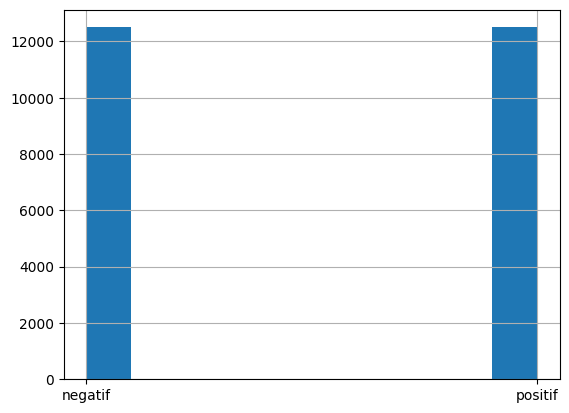

In [124]:
train_df.sentiment.hist()

In [125]:
from sklearn.model_selection import train_test_split

In [126]:
examples_df, gold_examples_df = train_test_split(
    train_df, test_size=0.2, random_state=123
    #0.2 cad 20% examples rest gold_examples
)

In [127]:
examples_df.shape, gold_examples_df.shape

((20000, 3), (5000, 3))

In [128]:
columns = ["text", "sentiment"]
gold_examples = (
                 gold_examples_df[columns]
                 .sample(20, random_state=34)
                 .to_json(orient="records")#Très pratique pour envoyer à un LLM/API.
                ) 

In [129]:
import json

In [130]:
json.loads(gold_examples)[0]

{'text': '"A Guy Thing" may not be a classic, but it sure is a good, funny comedy. The plot focuses on Paul (Jason Lee), who wakes up the morning after his bachelor party with no memory and Becky (Julia Stiles) lying naked in his bed. Before he can figure out what happened, he rushes Becky out of his apartment because his fiance Karen (Selma Blair) is coming. After that, as you could imagine, chaos ensues.<br /><br />Almost every single scene in "A Guy Thing" delivers loud laughs. The funniest moments come from when Paul imagines what could happen if he tells Karen. Selma Blair is a truly talented comedian, and the worst thing about this film is that she goes underused. Although, she turns out to be more funny than Stiles\' character, who actually isn\'t that interesting. Of course, not every comedy is perfect.<br /><br />As I said, "A Guy Thing" is no classic, but it\'s not bad either, 7/10.',
 'sentiment': 'positif'}

## Elaborer les prompts

#### Prompt 1: Zero-shot

In [131]:
user_prompt_template = """```{movie_review}```"""

In [132]:
zero_shot_system_message = """
Classify the sentiment of movie reviews presented in the input as 'positive' or 'negative'
Movie reviews will be delimited by triple backticks ``` in the input.
Answer only 'positive' or 'negative'
Do not explain your answer.
""" 

In [133]:
zero_shot_prompt = [
    {"role":"system", "content": zero_shot_system_message}
]

In [134]:
few_shot_system_message = """
Classify the sentiment of movie reviews presented in the input as 'positive' or 'negative'
Movie reviews will be delimited by triple backticks ``` in the input.
Answer only 'positive' or 'negative'
Do not explain your answer.
""" 

In [135]:
#pour le few shot prompt nous aurons besoin de quelques exemples variés, cad des critiques positives et négatives
#on va diviser les examples on deux (positif et negatif) et prendre 4 exemples de chaque pour les inclure in random order dans le prompt few shot
examples_df.shape

(20000, 3)

In [136]:
positif_reviews_df = (
        examples_df[examples_df.sentiment=="positif"][columns]
        .sample(4)
)

In [137]:
negatif_reviews_df = (
                examples_df[examples_df.sentiment=="negatif"][columns]
                .sample(4))

In [138]:
negatif_reviews_df

,text,sentiment
471,"Yesterday was Earth Day (April 22, 2009) in th...",negatif
10479,"..IT'S THIS ONE! Very cool premise, right off ...",negatif
10169,"Okay, just by reading the title you would thin...",negatif
2345,"I absolutely love all of Tom Robbins books, so...",negatif


In [139]:
positif_reviews_df.shape, negatif_reviews_df.shape

((4, 2), (4, 2))

In [140]:
import pandas as pd

In [141]:
ex = pd.concat([positif_reviews_df, negatif_reviews_df])

In [142]:
ex
#problème : les exemples positifs sont regroupés et les négatifs aussi, il faut les mélanger

,text,sentiment
23318,I turned this on to see the incredible Ethel W...,positif
21418,This movie came and went in the theaters. Due ...,positif
15670,"Last Christmas, I was lucky enough to receive ...",positif
23659,Low budget Brit pop melodrama focuses on a gir...,positif
471,"Yesterday was Earth Day (April 22, 2009) in th...",negatif
10479,"..IT'S THIS ONE! Very cool premise, right off ...",negatif
10169,"Okay, just by reading the title you would thin...",negatif
2345,"I absolutely love all of Tom Robbins books, so...",negatif


In [143]:
examples = examples_df.sample(4*2, replace=False).to_json(orient='records')

In [144]:
json.loads(examples)

[{'text': 'I was very impressed with this film. I would have to rate it as one of the better classic-era westerns. I say that for the whole thing: the acting, mature dialog, no- nonsense story and excellent cinematography.<br /><br />Director Anthony Mann, who did several well-photographed film noirs around this same era, also made some westerns such as this one. It has that same film-noir look. Mann and Jimmy Stewart collaborated on several westerns during this period. . If you like this movie, I recommend the Mann-Stewart film "Bend Of The River."<br /><br />In a nutshell, the story is about a man, "Lin McAdam," (Stewart) who owns this prestigious Winchester 73 rifle, a weapon he won fair-and-square in a contest. It is then stolen and passed on from villain to villain. All of those villains are interesting characters.<br /><br />Aiding Stewart act out this interesting tale are Shelley Winters, Dan Duryea, Stephen McNally, Millard Mitchell, Charles Drake, Will Greer and J. C. Flippen.

In [145]:
def create_examples(dataset, n=4):
    positive_reviews_df = (dataset[dataset["sentiment"] == 'positive'][columns].sample(n))
    negative_reviews_df = (dataset[dataset["sentiment"] == 'negative'][columns].sample(n))

    
    examples_df = pd.concat([positive_reviews_df, negative_reviews_df])
    examples = examples_df.sample(n*2, replace=False)
    
    return examples.to_json(orient='records')

In [146]:
examples_df.shape

(20000, 3)

In [147]:
examples = create_examples(examples_df, n=6)

ValueError: a must be greater than 0 unless no samples are taken